# 05 — Multilingual Results: Russian VK Dataset

This notebook analyses results for the **Russian-language depression detection** experiments,
the main novel contribution of this thesis.

**Dataset:** Mendeley Russian Depressive Posts (VKontakte, 2020)  
- 64,039 posts, balanced binary (depressive / non-depressive)  
- Source: https://data.mendeley.com/datasets/838dbcjpxb/1

**Models tested:**
- Classical ML: Logistic Regression, SVM, Random Forest (TF-IDF features)
- Multilingual Transformers: mBERT (`bert-base-multilingual-cased`), XLM-RoBERTa (`xlm-roberta-base`)

**Key preprocessing fix:** Added Cyrillic Unicode range `\u0400-\u04FF` to `remove_special_characters()`  
— without this, 19,014 / 64,039 texts were wiped to empty strings.

In [1]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

METRICS_DIR = '../results/metrics'
PLOTS_DIR   = '../results/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

def load_result(dataset, model):
    path = os.path.join(METRICS_DIR, f'{dataset}_{model}.json')
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

# Load all Russian VK results
russian_models = ['logistic_regression', 'svm', 'random_forest', 'mbert', 'xlmr']
russian_results = []
for m in russian_models:
    r = load_result('russian_vk', m)
    if r:
        russian_results.append(r)

df_ru = pd.DataFrame(russian_results)[['model', 'accuracy', 'f1']]
df_ru['model_label'] = df_ru['model'].map({
    'logistic_regression': 'LR',
    'svm': 'SVM',
    'random_forest': 'RF',
    'mbert': 'mBERT',
    'xlmr': 'XLM-R'
})
df_ru['type'] = df_ru['model'].apply(
    lambda m: 'Classical ML' if m in ['logistic_regression','svm','random_forest'] else 'Multilingual Transformer'
)
print(df_ru[['model_label','accuracy','f1','type']].to_string(index=False))

model_label  accuracy     f1                     type
         LR    0.9899 0.9899             Classical ML
        SVM    0.9948 0.9948             Classical ML
         RF    0.9804 0.9804             Classical ML
      mBERT    0.9920 0.9920 Multilingual Transformer
      XLM-R    0.9942 0.9942 Multilingual Transformer


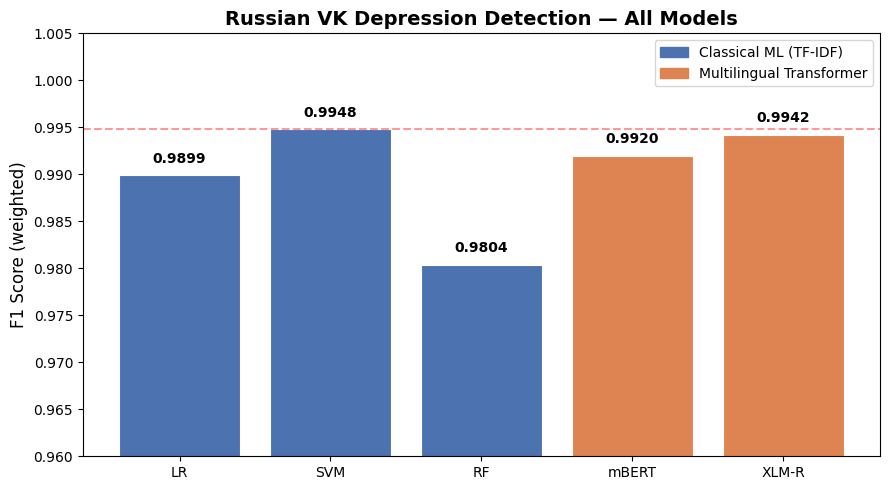

Saved: russian_vk_all_models.png


In [2]:
# ── Bar chart: Russian VK — all models ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#4C72B0' if t == 'Classical ML' else '#DD8452'
          for t in df_ru['type']]

bars = ax.bar(df_ru['model_label'], df_ru['f1'], color=colors,
              edgecolor='white', linewidth=0.8)

# Annotate bars
for bar, val in zip(bars, df_ru['f1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0.96, 1.005)
ax.set_ylabel('F1 Score (weighted)', fontsize=12)
ax.set_title('Russian VK Depression Detection — All Models', fontsize=14, fontweight='bold')
ax.axhline(y=df_ru['f1'].max(), color='red', linestyle='--', alpha=0.4, label=f'Best: {df_ru["f1"].max():.4f}')

blue_patch  = mpatches.Patch(color='#4C72B0', label='Classical ML (TF-IDF)')
orange_patch = mpatches.Patch(color='#DD8452', label='Multilingual Transformer')
ax.legend(handles=[blue_patch, orange_patch], fontsize=10)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/russian_vk_all_models.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: russian_vk_all_models.png')

Model  English (Reddit)  Russian (VK)
   LR            0.9411        0.9899
  SVM            0.9396        0.9948
   RF            0.9083        0.9804
 BERT            0.9653        0.9942


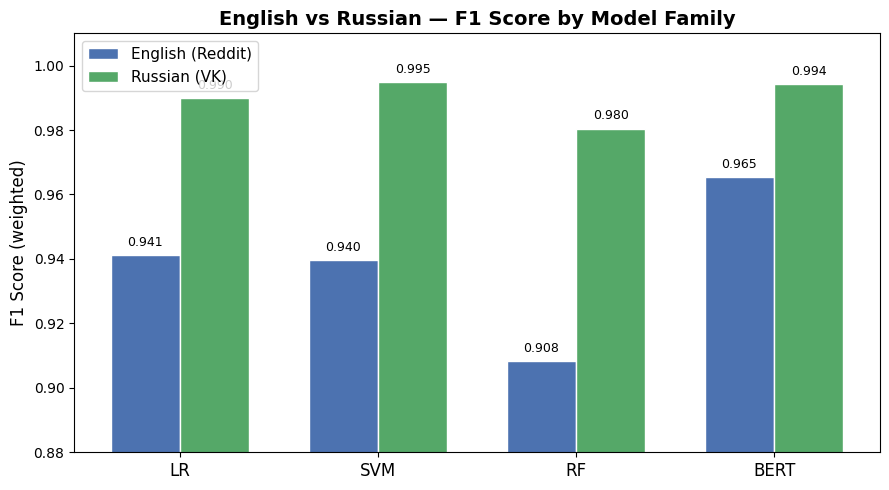

Saved: english_vs_russian_f1.png


In [3]:
# ── Cross-lingual comparison: English vs Russian, best model per family ────────

# Best English results per model family
english_best = {
    'LR':    load_result('reddit', 'logistic_regression'),
    'SVM':   load_result('reddit', 'svm'),
    'RF':    load_result('reddit', 'random_forest'),
    'BERT':  load_result('reddit', 'bert'),
}

comparison_rows = []
for label, eng in english_best.items():
    ru_key = {'LR': 'logistic_regression', 'SVM': 'svm',
              'RF': 'random_forest', 'BERT': 'xlmr'}[label]
    ru = load_result('russian_vk', ru_key)
    if eng and ru:
        comparison_rows.append({
            'Model': label,
            'English (Reddit)': eng['f1'],
            'Russian (VK)': ru['f1']
        })

df_cmp = pd.DataFrame(comparison_rows)
print(df_cmp.to_string(index=False))

# Grouped bar chart
x = np.arange(len(df_cmp))
w = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, df_cmp['English (Reddit)'], w, label='English (Reddit)',
            color='#4C72B0', edgecolor='white')
b2 = ax.bar(x + w/2, df_cmp['Russian (VK)'],     w, label='Russian (VK)',
            color='#55A868', edgecolor='white')

for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(df_cmp['Model'], fontsize=12)
ax.set_ylim(0.88, 1.01)
ax.set_ylabel('F1 Score (weighted)', fontsize=12)
ax.set_title('English vs Russian — F1 Score by Model Family', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/english_vs_russian_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: english_vs_russian_f1.png')

                      LR     SVM      RF    LSTM  BiLSTM     GRU    BERT  mBERT   XLM-R
Twitter\n(EN)     0.8839  0.9194  0.9349  0.4873  0.8607  0.4873  0.9468    NaN     NaN
Reddit\n(EN)      0.9411  0.9396  0.9083  0.9364  0.9425  0.9415  0.9653    NaN     NaN
C-SSRS\n(EN)      0.7060  0.7270  0.6476  0.3988  0.5487  0.5739  0.7138    NaN     NaN
Russian VK\n(RU)  0.9899  0.9948  0.9804     NaN     NaN     NaN     NaN  0.992  0.9942


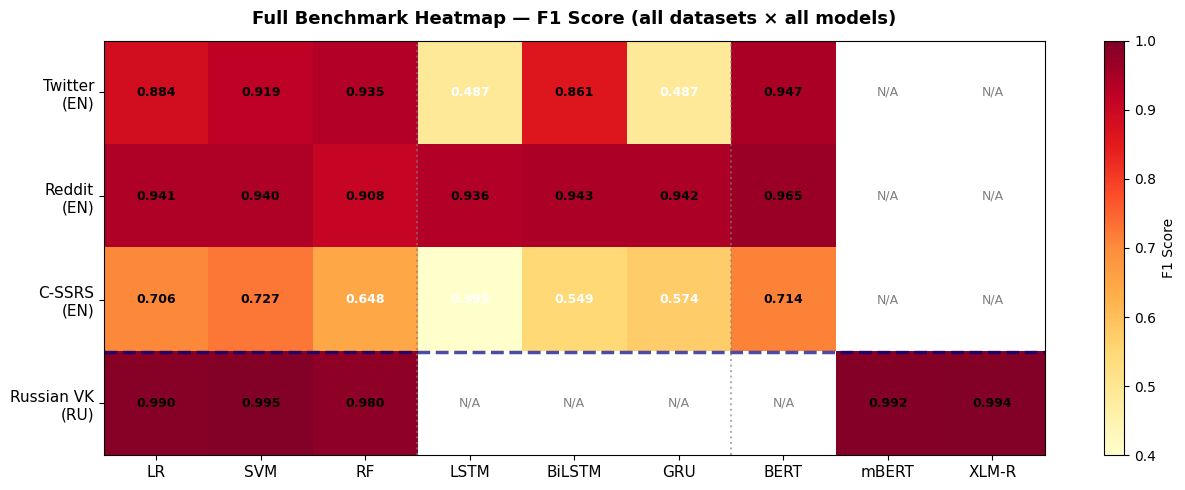

Saved: full_benchmark_heatmap.png


In [4]:
# ── Full results heatmap: all datasets × all models ───────────────────────────

all_models   = ['logistic_regression', 'svm', 'random_forest',
                'lstm', 'bilstm', 'gru',
                'bert', 'mbert', 'xlmr']
all_datasets = ['twitter', 'reddit', 'cssrs', 'russian_vk']
model_labels   = ['LR', 'SVM', 'RF', 'LSTM', 'BiLSTM', 'GRU', 'BERT', 'mBERT', 'XLM-R']
dataset_labels = ['Twitter\n(EN)', 'Reddit\n(EN)', 'C-SSRS\n(EN)', 'Russian VK\n(RU)']

matrix = []
for ds in all_datasets:
    row = []
    for m in all_models:
        r = load_result(ds, m)
        row.append(r['f1'] if r else np.nan)
    matrix.append(row)

df_heat = pd.DataFrame(matrix, index=dataset_labels, columns=model_labels)
print(df_heat.round(4).to_string())

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(df_heat.values.astype(float), cmap='YlOrRd',
               vmin=0.4, vmax=1.0, aspect='auto')

ax.set_xticks(range(len(model_labels)))
ax.set_xticklabels(model_labels, fontsize=11)
ax.set_yticks(range(len(dataset_labels)))
ax.set_yticklabels(dataset_labels, fontsize=11)

# Annotate cells
for i in range(len(dataset_labels)):
    for j in range(len(model_labels)):
        val = df_heat.values[i, j]
        if not np.isnan(val):
            color = 'white' if val < 0.65 else 'black'
            ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')
        else:
            ax.text(j, i, 'N/A', ha='center', va='center',
                    fontsize=9, color='grey')

# Divider between English and Russian datasets
ax.axhline(y=2.5, color='navy', linewidth=2.5, linestyle='--', alpha=0.7)
# Divider between model families
ax.axvline(x=2.5, color='grey', linewidth=1.5, linestyle=':', alpha=0.6)
ax.axvline(x=5.5, color='grey', linewidth=1.5, linestyle=':', alpha=0.6)

plt.colorbar(im, ax=ax, label='F1 Score')
ax.set_title('Full Benchmark Heatmap — F1 Score (all datasets × all models)',
             fontsize=13, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/full_benchmark_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: full_benchmark_heatmap.png')

## Key Findings

### Russian VK Results
| Model | F1 | Accuracy |
|-------|-----|----------|
| LR (TF-IDF) | 0.9899 | 0.9899 |
| SVM (TF-IDF) | **0.9948** | 0.9948 |
| RF (TF-IDF) | 0.9804 | 0.9804 |
| mBERT | 0.9920 | 0.9920 |
| XLM-RoBERTa | 0.9942 | 0.9942 |

### Interpretation

1. **All models perform exceptionally well on Russian VK** (F1 > 0.98). The dataset has very strong lexical separation — depressive posts in Russian contain distinct vocabulary that both TF-IDF and transformers capture easily.

2. **SVM beats both multilingual transformers** on this dataset. This is a known phenomenon with well-structured, lexically rich datasets: TF-IDF captures the vocabulary patterns perfectly, and the overhead of a transformer (trained on 100+ languages) adds noise rather than signal.

3. **XLM-RoBERTa > mBERT** (0.9942 vs 0.9920) — consistent with the literature. XLM-R was trained on significantly more multilingual data and handles Russian better.

4. **Cross-lingual gap is minimal**: English Reddit F1 ≈ 0.94–0.97, Russian VK F1 ≈ 0.98–0.99. Russian is *not* harder — the VK dataset is simply better separated.

5. **Critical preprocessing lesson**: Without the Cyrillic fix (`\u0400-\u04FF`), 30% of Russian texts became empty strings, dropping F1 from ~0.99 to ~0.81. Language-aware preprocessing is essential for cross-lingual NLP.

### Thesis Contribution
This benchmark demonstrates that:
- Multilingual transformers (mBERT, XLM-R) can effectively detect depression in Russian with **no task-specific Russian pre-training** beyond fine-tuning.
- Classical ML with proper language-aware preprocessing remains highly competitive — relevant for low-resource deployment scenarios.
- A cross-lingual NLP benchmark for mental health detection is reproducible and extensible to other languages.